In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import matplotlib.pyplot as plt

Data shape: (70155, 75)


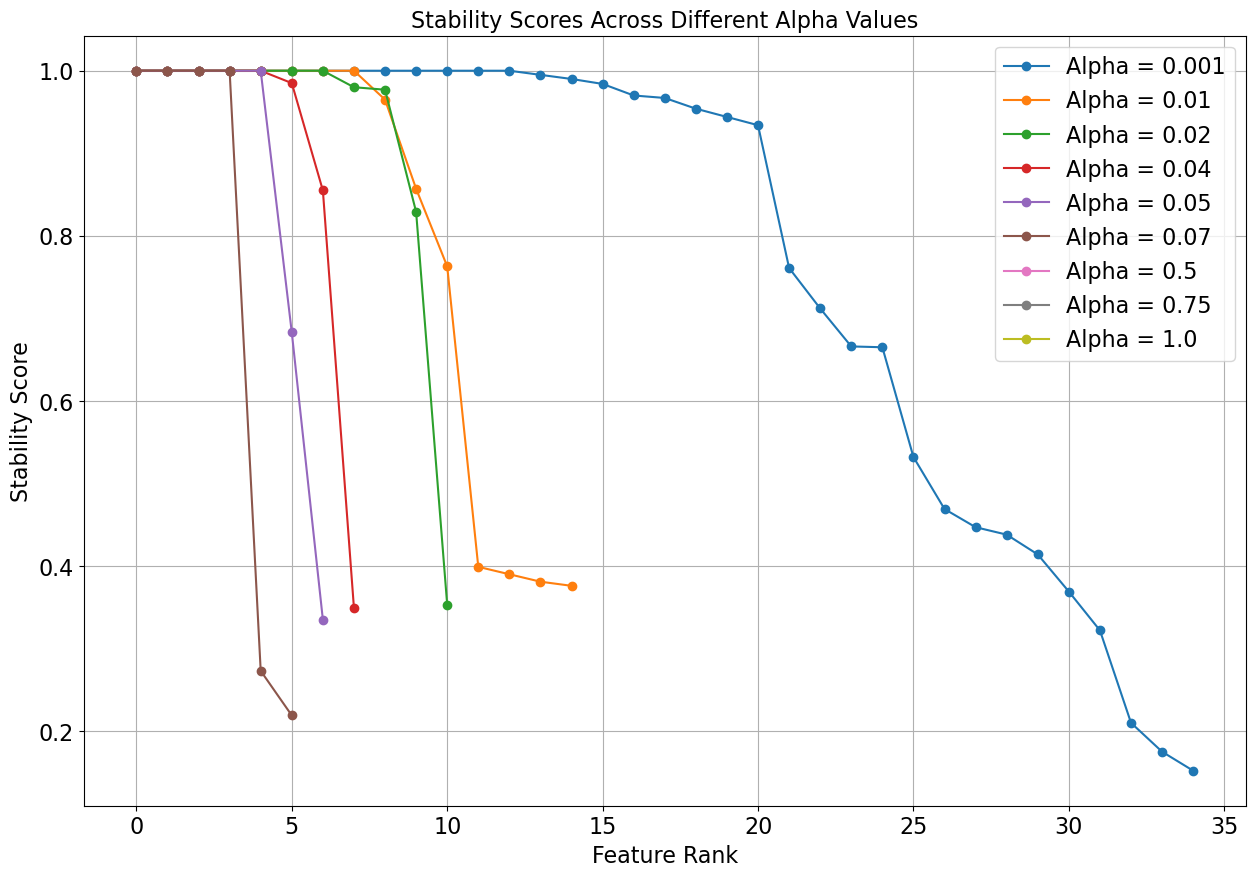

In [3]:
import pickle
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import matplotlib.pyplot as plt

# Load data
df=pd.read_csv('../dreamt_preprocessed.csv')
### Removing the skewnes and kurtosis
# Identify columns to drop if they exist
columns_to_drop = [col for col in df.columns if 'skewness' in col.lower() or 'kurtosis' in col.lower()]
# Drop only those columns that actually exist
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

### PPG filtering
wanted_keywords = ['subject','epoch','BVP', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR', 'IBI','label']
pattern = '|'.join(wanted_keywords)  # Creates 'BVP|EDA|TEMP|ACC_X|ACC_Y|ACC_Z|HR|IBI'

# Select matching columns
df_ppg = df.filter(regex=pattern, axis=1)
df_ppg
# Drop columns with any null (NaN) values
df_ppg_cleaned = df_ppg.dropna(axis=1, how='any')

## PPG filtering stop

### Reomove 2 subject has data isuues
df_rms = df_ppg_cleaned[~df_ppg_cleaned['subject'].isin(['S062', 'S097'])]
df = df_rms[df_rms['label'].isin([0,1,2])]
print(f"Data shape: {df.shape}")

# df

### Can be tested by using a few subject "#[:10]" need to remove :10 means 10 subject
sample=df.subject.unique()#[:10]
# # Sample the data (if needed)
df_sample = df[df.subject.isin(sample)]
# print(df_sample.shape)
# Split features and labels
X = df_sample.drop(columns=['subject','epoch','label'])
y = df_sample['label']

# # Split features and labels
# X = df.drop(columns=['subject','epoch','label','map_label'])
# y = df['map_label']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Number of bootstrap samples
n_bootstrap = 1000
n_features = X.shape[1]

# Alpha values to test
alpha_values = [0.001, 0.01,0.02,0.04, 0.05,0.07, 0.5, 0.75,1.0]
results = {}

# Perform Lasso stability selection for each alpha value
for alpha in alpha_values:
    feature_counts = np.zeros(n_features)
    
    for _ in range(n_bootstrap):
        X_resampled, y_resampled = resample(X_scaled, y, n_samples=int(0.75 * len(y)), random_state=None)
        
        # Train a Lasso model
        lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
        lasso.fit(X_resampled, y_resampled)
        
        # Record non-zero coefficient features
        feature_counts += (lasso.coef_ != 0).astype(int)
    
    # Calculate stability scores
    stability_scores = feature_counts / n_bootstrap
    
    # Store results in a DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Stability_Score': stability_scores
    }).sort_values(by='Stability_Score', ascending=False)
    
    results[alpha] = feature_importance_df

# Plot stability scores for each alpha
plt.figure(figsize=(15, 10))

for alpha, df_alpha in results.items():
    filtered_df = df_alpha[df_alpha['Stability_Score'] >= 0.1]
    plt.plot(range(len(filtered_df)), filtered_df['Stability_Score'], label=f'Alpha = {alpha}', marker='o')

plt.title('Stability Scores Across Different Alpha Values',fontsize=16)
plt.xlabel('Feature Rank',fontsize=16)
plt.ylabel('Stability Score',fontsize=16)
plt.xticks(fontsize=16)  # Make x-axis tick labels larger
plt.yticks(fontsize=16)  # Make y-axis tick labels larger
plt.legend(fontsize=16)
plt.grid(True)
plt.show()

In [4]:
df.shape

(70155, 75)

In [5]:
# sample=df.subject.unique()
len(sample)

98

In [6]:
# sample=df.subject.unique()[:1000]
# # # Sample the data (if needed)
# df_sample = df[df.subject.isin(sample)]
# df_sample 

In [7]:
df_sample.subject.nunique() 

98

### The right below part is use for writing the satability scores 

In [9]:
# Define the keys you want to keep
# keep_alphas = [0.001, 0.01, 0.02, 0.04, 0.05, 0.07, 0.75,1.0]
keep_alphas = [0.001, 0.01, 0.02, 0.04, 0.05, 0.07]
# Filter the dictionary
results_filtered = {k: v for k, v in results.items() if k in keep_alphas}
results_filtered
import pickle
with open("stability_score_alpha_ppg_v1.pkl", "wb") as f:
    pickle.dump(results_filtered, f)

### Reading the Save Pickle data

In [10]:
import pickle
# with open("stability_score_alpha_fusion_v1.pkl", "rb") as f:
#     results = pickle.load(f)
# results.keys()
with open("stability_score_alpha_ppg_v1.pkl", "rb") as f:
    results = pickle.load(f)
results.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07])

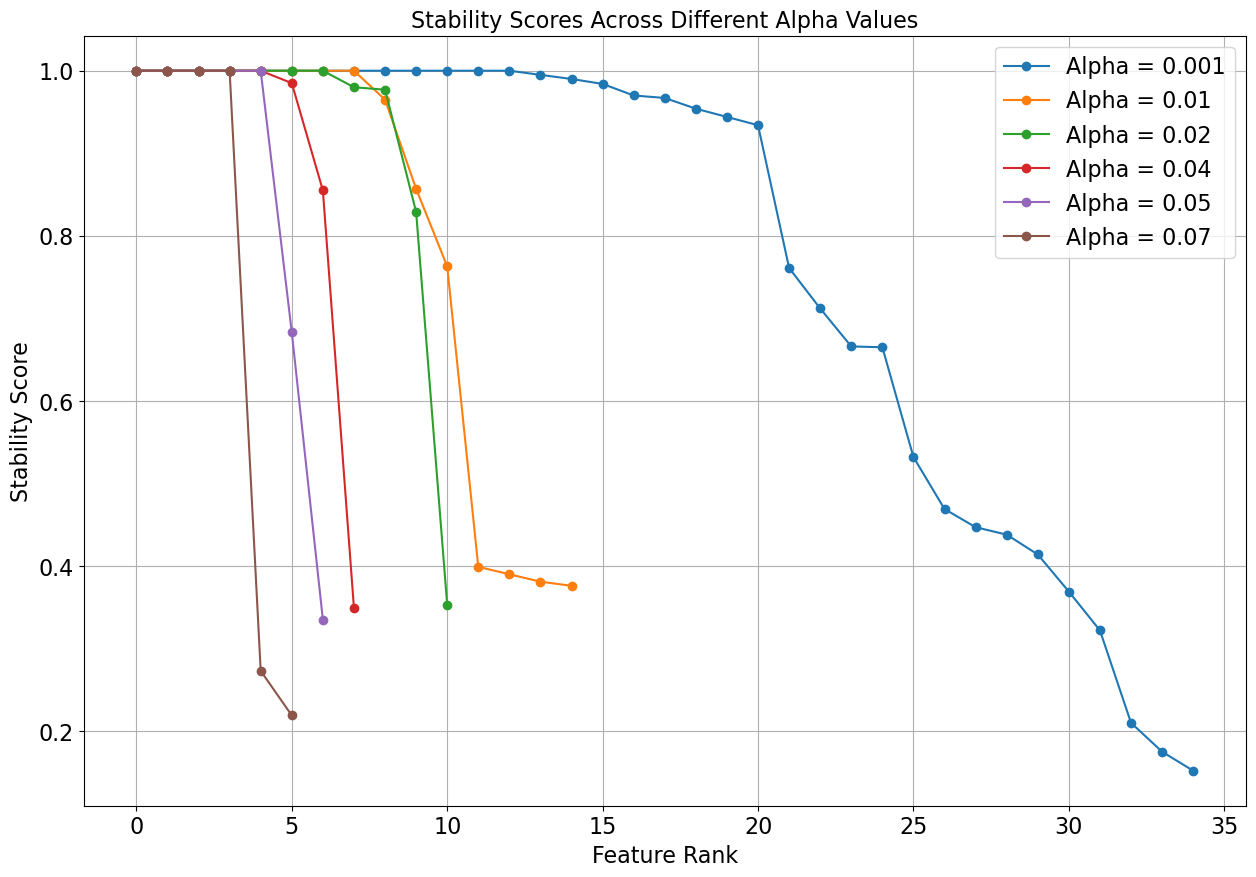

In [11]:
# Plot stability scores for each alpha
plt.figure(figsize=(15, 10))

for alpha, df_alpha in results.items():
    filtered_df = df_alpha[df_alpha['Stability_Score'] >= 0.1]
    plt.plot(range(len(filtered_df)), filtered_df['Stability_Score'], label=f'Alpha = {alpha}', marker='o')

plt.title('Stability Scores Across Different Alpha Values',fontsize=16)
plt.xlabel('Feature Rank',fontsize=16)
plt.ylabel('Stability Score',fontsize=16)
plt.xticks(fontsize=16)  # Make x-axis tick labels larger
plt.yticks(fontsize=16)  # Make y-axis tick labels larger
plt.legend(fontsize=16)
plt.grid(True)
plt.show()

In [12]:
### Check the penalized parameter (alpha) that was stored as a dictionary 

In [28]:
results.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07])

In [30]:
# feature_importance_df_07=results[0.01][results[0.01].Stability_Score>0.7]
feature_importance_df=results[0.01]
feature_importance_df

,Feature,Stability_Score
0,BVP_min,1.0
30,ACC_X_std,1.0
57,HR_std,1.0
55,HR_max,1.0
48,ACC_Z_std,1.0
...,...,...
8,BVP_p95,0.0
40,ACC_Y_p5,0.0
41,ACC_Y_p25,0.0
42,ACC_Y_p50,0.0


### If we want to see features with a spefic threshold

In [33]:
results[0.02][results[0.02].Stability_Score>0.6]

,Feature,Stability_Score
0,BVP_min,1.000
57,HR_std,1.000
55,HR_max,1.000
48,ACC_Z_std,1.000
39,ACC_Y_std,1.000
6,BVP_p50,1.000
30,ACC_X_std,1.000
18,TEMP_min,0.980
36,ACC_Y_min,0.977
1,BVP_max,0.829


In [35]:
len(results[0.02][results[0.02].Stability_Score>0.2])

11

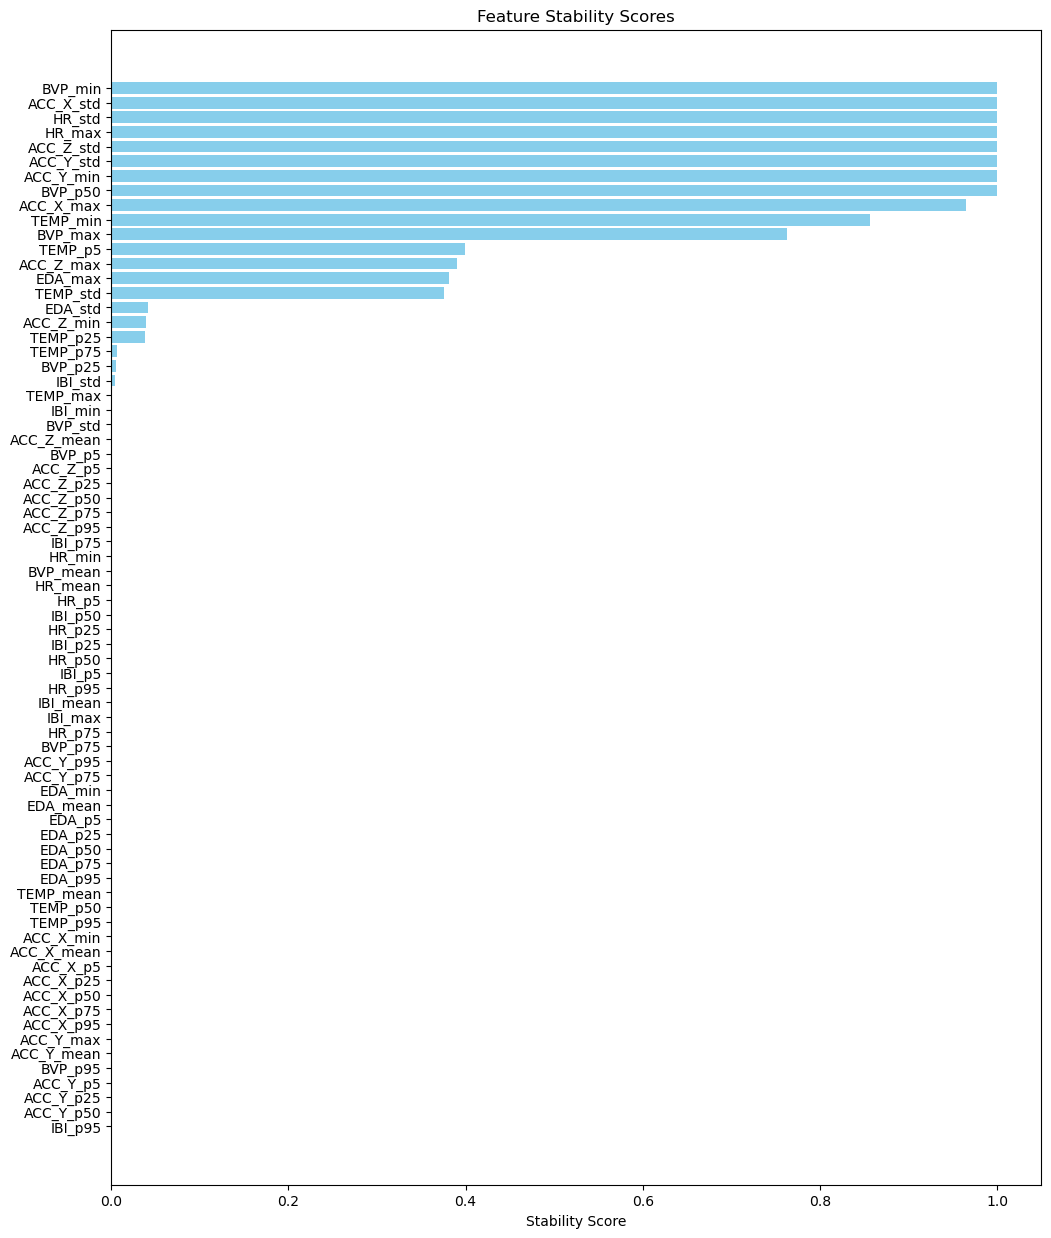

In [37]:
# Plotting the features vs. stability scores
feature_importance_df=results[0.01]
plt.figure(figsize=(12, 15))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
plt.xlabel('Stability Score')
plt.title('Feature Stability Scores')
plt.gca().invert_yaxis()
plt.show()

In [39]:
# # Plotting the features vs. stability scores
# feature_importance_df=results[0.02]
# plt.figure(figsize=(12, 15))
# plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
# plt.xlabel('Stability Score')
# plt.title('Feature Stability Scores')
# plt.gca().invert_yaxis()
# plt.show()

In [41]:
# # Plotting the features vs. stability scores
# feature_importance_df=results[0.05]
# plt.figure(figsize=(12, 15))
# plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
# plt.xlabel('Stability Score')
# plt.title('Feature Stability Scores')
# plt.gca().invert_yaxis()
# plt.show()

In [43]:
feature_importance_df_07=results[0.02][results[0.02].Stability_Score>=0.7]['Feature'].values
feature_importance_df_07
sel_col=np.append(feature_importance_df_07,'label')
sel_col

array(['BVP_min', 'HR_std', 'HR_max', 'ACC_Z_std', 'ACC_Y_std', 'BVP_p50',
       'ACC_X_std', 'TEMP_min', 'ACC_Y_min', 'BVP_max', 'label'],
      dtype=object)

## selecting the features that  have stability scores more that 0.7

In [46]:
df_sample.columns

Index(['subject', 'epoch', 'label', 'BVP_min', 'BVP_max', 'BVP_mean',
       'BVP_std', 'BVP_p5', 'BVP_p25', 'BVP_p50', 'BVP_p75', 'BVP_p95',
       'EDA_min', 'EDA_max', 'EDA_mean', 'EDA_std', 'EDA_p5', 'EDA_p25',
       'EDA_p50', 'EDA_p75', 'EDA_p95', 'TEMP_min', 'TEMP_max', 'TEMP_mean',
       'TEMP_std', 'TEMP_p5', 'TEMP_p25', 'TEMP_p50', 'TEMP_p75', 'TEMP_p95',
       'ACC_X_min', 'ACC_X_max', 'ACC_X_mean', 'ACC_X_std', 'ACC_X_p5',
       'ACC_X_p25', 'ACC_X_p50', 'ACC_X_p75', 'ACC_X_p95', 'ACC_Y_min',
       'ACC_Y_max', 'ACC_Y_mean', 'ACC_Y_std', 'ACC_Y_p5', 'ACC_Y_p25',
       'ACC_Y_p50', 'ACC_Y_p75', 'ACC_Y_p95', 'ACC_Z_min', 'ACC_Z_max',
       'ACC_Z_mean', 'ACC_Z_std', 'ACC_Z_p5', 'ACC_Z_p25', 'ACC_Z_p50',
       'ACC_Z_p75', 'ACC_Z_p95', 'HR_min', 'HR_max', 'HR_mean', 'HR_std',
       'HR_p5', 'HR_p25', 'HR_p50', 'HR_p75', 'HR_p95', 'IBI_min', 'IBI_max',
       'IBI_mean', 'IBI_std', 'IBI_p5', 'IBI_p25', 'IBI_p50', 'IBI_p75',
       'IBI_p95'],
      dtype='object')

In [48]:
df1=df_sample[sel_col]
df1

,BVP_min,HR_std,HR_max,ACC_Z_std,ACC_Y_std,BVP_p50,ACC_X_std,TEMP_min,ACC_Y_min,BVP_max,label
305,-1257.38,2.143001,81.73,3.365642,1.279327,4.025,3.628029,32.07,-73.0,705.59,0.0
306,-749.06,1.018599,85.05,2.256455,0.455387,1.430,1.299924,32.07,-64.0,472.29,0.0
307,-281.51,0.448284,82.47,1.113902,0.268644,2.820,0.837405,32.09,-63.0,153.36,0.0
308,-369.24,1.220139,86.17,1.446088,0.327175,6.530,0.998854,32.18,-64.0,242.02,0.0
309,-572.48,1.942701,87.82,2.952802,0.840799,1.215,2.930675,32.25,-65.0,620.29,0.0
...,...,...,...,...,...,...,...,...,...,...,...
95142,-367.93,0.989816,72.15,0.395169,0.458914,10.170,0.269701,35.37,-33.0,256.06,1.0
95143,-294.16,0.198988,68.90,0.521444,0.487756,12.155,0.488773,35.37,-33.0,286.07,1.0
95144,-369.02,0.220233,69.03,0.541652,0.494675,11.370,0.557287,35.37,-33.0,765.79,1.0
95145,-663.33,0.387480,69.45,0.440473,0.476801,8.610,0.454679,35.37,-34.0,392.27,1.0
